In [237]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [238]:
# Import data set 
file_path = "/Users/ethaneckenrode/Desktop/7.1_drug_seizures_2019-2023.csv"
df = pd.read_csv(file_path)

# df.head()

In [239]:
print("Shape (rows, cols):", df.shape)
df.info()
df.describe(include="all").T.head(20)

Shape (rows, cols): (11274, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11274 entries, 0 to 11273
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Region          11274 non-null  object 
 1   SubRegion       11274 non-null  object 
 2   Country         11274 non-null  object 
 3   DrugGroup       11274 non-null  object 
 4   DrugSubGroup    11274 non-null  object 
 5   DrugName        11274 non-null  object 
 6   Reference year  11274 non-null  int64  
 7   Kilograms       11198 non-null  float64
 8   msCode          11274 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 792.8+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Region,11274,5,Europe,5380,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SubRegion,11274,16,Western and Central Europe,4202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,11274,164,Canada,459,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DrugGroup,11274,11,Opioids,2685,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DrugSubGroup,11274,49,Opiates,1306,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DrugName,11274,156,Cannabis herb (marijuana),697,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Reference year,11274.0,NaN,NaN,NaN,2021.028827,1.393667,2019.0,2020.0,2021.0,2022.0,2023.0
Kilograms,11198.0,NaN,NaN,NaN,16948.88196,279370.590641,0.0,0.028455,3.0,152.5625,15734375.8
msCode,11274,164,CAN,459,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [240]:
missing = df.isna().mean().sort_values(ascending=False)
missing.head(15)

Kilograms         0.006741
Region            0.000000
SubRegion         0.000000
DrugGroup         0.000000
Country           0.000000
DrugSubGroup      0.000000
DrugName          0.000000
Reference year    0.000000
msCode            0.000000
dtype: float64

In [241]:
date_col = "reference_year"
drug_col = "druggroup"
qty_col  = "kilograms"
region_col = "region"
country_col = "country"

In [242]:
df.duplicated().sum()

np.int64(244)

In [243]:
df = df.copy()
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("-", "_")
)
df.columns

Index(['region', 'subregion', 'country', 'druggroup', 'drugsubgroup',
       'drugname', 'reference_year', 'kilograms', 'mscode'],
      dtype='object')

In [244]:
if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    print("Null dates after parsing:", df[date_col].isna().sum())

Null dates after parsing: 0


In [245]:
if drug_col:
    df[drug_col] = (
        df[drug_col]
          .astype(str)
          .str.strip()
          .str.lower()
          .replace({"nan": np.nan})
    )
    df[drug_col].value_counts().head(15)

In [246]:
if qty_col:
    # remove commas/units if they exist and coerce to numeric
    df[qty_col] = (
        df[qty_col]
          .astype(str)
          .str.replace(",", "", regex=False)
          .str.replace(r"[^\d.]+", "", regex=True)  # keep digits/decimal only
    )
    df[qty_col] = pd.to_numeric(df[qty_col], errors="coerce")
    df[qty_col].describe()

In [247]:
before = len(df)

required = []
if drug_col: required.append(drug_col)
if date_col: required.append(date_col)

if required:
    df_clean = df.dropna(subset=required).copy()
else:
    df_clean = df.copy()

after = len(df_clean)
print("Rows before:", before, "Rows after:", after, "Dropped:", before-after)

Rows before: 11274 Rows after: 11274 Dropped: 0


In [248]:
# Column mapping (final, correct)
date_col = "reference_year"
drug_col = "druggroup"
qty_col = "kilograms"
region_col = "region"
country_col = "country"

# Ensure numeric types
df[date_col] = pd.to_numeric(df[date_col], errors="coerce")
df[qty_col] = pd.to_numeric(df[qty_col], errors="coerce")

# Build clean dataset for analysis
df_clean = df.dropna(subset=[date_col, qty_col, drug_col, region_col]).copy()
df_clean = df_clean[df_clean[qty_col] > 0]

print("Clean shape:", df_clean.shape)
df_clean.head()

Clean shape: (10359, 9)


,region,subregion,country,druggroup,drugsubgroup,drugname,reference_year,kilograms,mscode
0,Africa,East Africa,Comoros,any other drugs/substances,Other miscellaneous,Other drugs/substances,2023,45.0,COM
1,Africa,East Africa,Comoros,cannabis-type drugs (excluding synthetic canna...,Cannabis herb (marijuana),Cannabis herb (marijuana),2023,2263.0,COM
2,Africa,East Africa,Comoros,cannabis-type drugs (excluding synthetic canna...,Cannabis resin (hashish),Cannabis resin (hashish),2023,57.5,COM
3,Africa,East Africa,Comoros,nps,Synthetic cannabinoids (Spice),Synthetic cannabinoids (“Spice”),2023,10.0,COM
4,Africa,East Africa,Comoros,opioids,Opiates,Heroin,2023,0.5,COM


In [249]:
date_col = "reference_year"   
state_col = None              
drug_col = "druggroup"       
qty_col  = "kilograms"
region_col = "region"
country_col = "country"

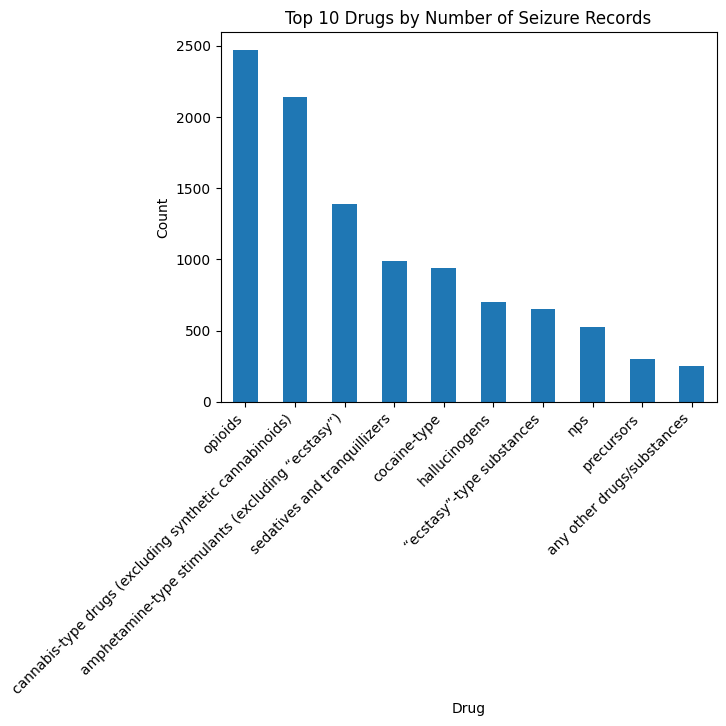

In [250]:
if drug_col:
    top_drugs = df_clean[drug_col].value_counts().head(10)

    top_drugs.plot(kind="bar")
    plt.title("Top 10 Drugs by Number of Seizure Records")
    plt.xlabel("Drug")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.show()

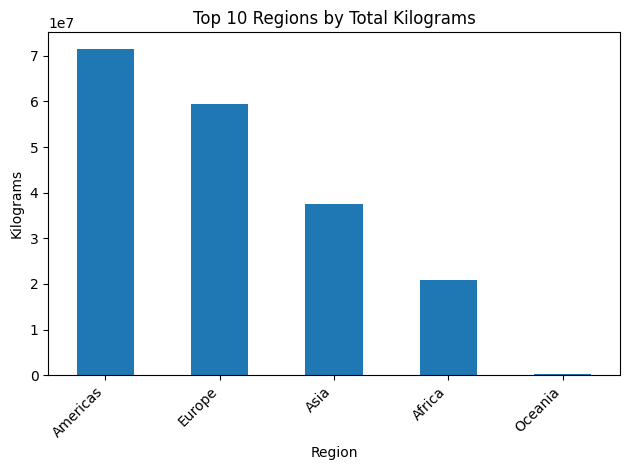

In [251]:
top_regions = df_clean.groupby("region")["kilograms"].sum().sort_values(ascending=False).head(10)

top_regions.plot(kind="bar")
plt.title("Top 10 Regions by Total Kilograms")
plt.xlabel("Region")
plt.ylabel("Kilograms")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

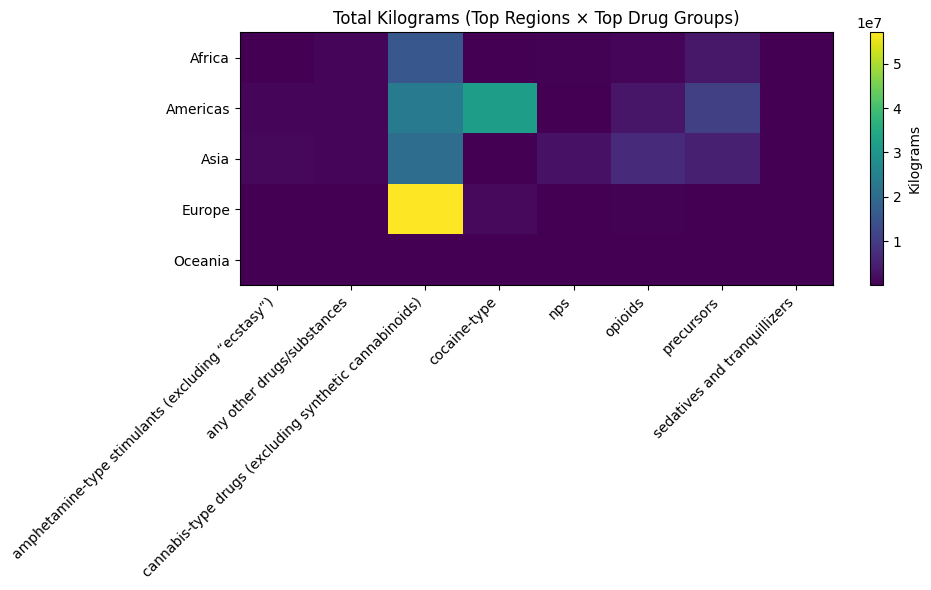

In [252]:
top_regions = df_clean.groupby("region")["kilograms"].sum().sort_values(ascending=False).head(8).index
top_drugs = df_clean.groupby("druggroup")["kilograms"].sum().sort_values(ascending=False).head(8).index

pivot = (
    df_clean[df_clean["region"].isin(top_regions) & df_clean["druggroup"].isin(top_drugs)]
    .pivot_table(index="region", columns="druggroup", values="kilograms", aggfunc="sum", fill_value=0)
)

plt.figure(figsize=(10,6))
plt.imshow(pivot.values, aspect="auto")
plt.title("Total Kilograms (Top Regions × Top Drug Groups)")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha="right")
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label="Kilograms")
plt.tight_layout()
plt.show()

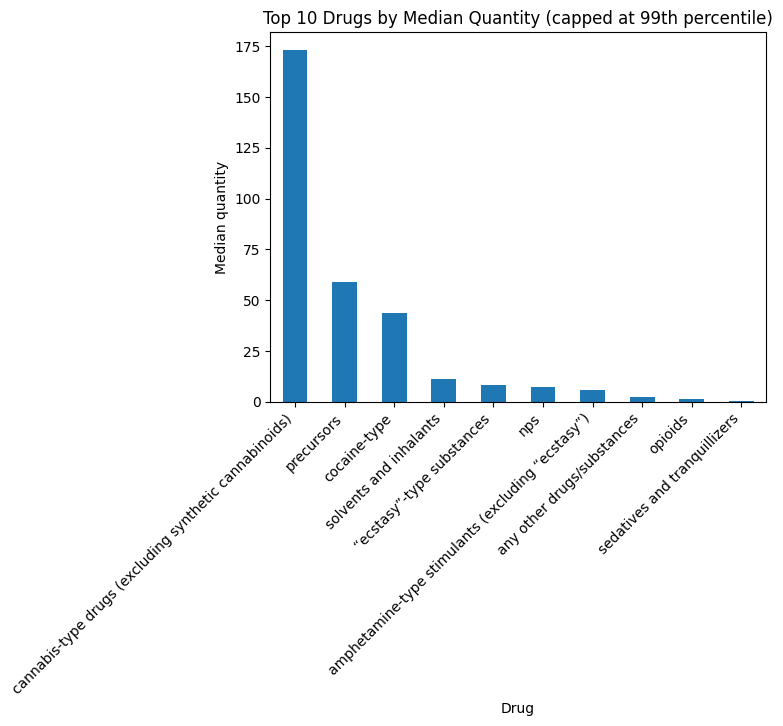

In [253]:
if drug_col and qty_col:
    # avoid extreme outliers messing up charts
    subset = df_clean.dropna(subset=[qty_col]).copy()
    if len(subset) > 0:
        cap = subset[qty_col].quantile(0.99)
        subset = subset[subset[qty_col] <= cap]

        by_drug_qty = subset.groupby(drug_col)[qty_col].median().sort_values(ascending=False).head(10)

        by_drug_qty.plot(kind="bar")
        plt.title("Top 10 Drugs by Median Quantity (capped at 99th percentile)")
        plt.xlabel("Drug")
        plt.ylabel("Median quantity")
        plt.xticks(rotation=45, ha="right")
        plt.show()

In [254]:
summary = {}

if drug_col:
    summary["top_drugs_count"] = df_clean[drug_col].value_counts().head(10)

if state_col:
    summary["top_states_count"] = df_clean[state_col].value_counts().head(10)

summary

{'top_drugs_count': druggroup
 opioids                                                   2472
 cannabis-type drugs (excluding synthetic cannabinoids)    2137
 amphetamine-type stimulants (excluding “ecstasy”)         1387
 sedatives and tranquillizers                               986
 cocaine-type                                               940
 hallucinogens                                              699
 “ecstasy”-type substances                                  652
 nps                                                        524
 precursors                                                 297
 any other drugs/substances                                 251
 Name: count, dtype: int64}

In [255]:
out_path = os.path.join(os.path.dirname(file_path), "drug_seizures_clean.csv")
df_clean.to_csv(out_path, index=False)
out_path

'/Users/ethaneckenrode/Desktop/drug_seizures_clean.csv'